In [1]:
import numpy as np
import pandas as pd
import time
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

In [2]:
import os
import json

output_dir = 'outputs'
figures_dir = os.path.join(output_dir, 'figures')

os.makedirs(output_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

In [3]:
print("Loading data...")

train_data = np.load(r'F:\AIL\m04_augmented_features_hog_gray_color_hist_pad_square_64_aug2_debugFalse.npz')
X_train = train_data['X_train_aug'] if 'X_train_aug' in train_data else train_data['arr_0']
y_train = train_data['y_train_aug'] if 'y_train_aug' in train_data else train_data['arr_1']

test_data = np.load(r'F:\AIL\m04_test_features_hog_gray_color_hist_pad_square_64_debugFalse.npz')
X_test = test_data['X_test'] if 'X_test' in test_data else test_data['arr_0']
y_test = test_data['y_test'] if 'y_test' in test_data else test_data['arr_1']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Applying PCA (95% variance)...")
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Number of components after PCA: {X_train_pca.shape[1]}")

Loading data...
Applying PCA (95% variance)...
Number of components after PCA: 571


In [4]:
models = {
    "SVC (RBF)": SVC(kernel='rbf', random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_jobs=-1),
    "MLP": MLPClassifier(max_iter=1000, random_state=42)
}

classes = np.unique(y_test)

minority_classes = ['R.301e', 'W.205c', 'I.409', 'S.505a_Xe máy', 'W.205a', 'W.225', 'P.124d', 'W.203c', 'P.103a', 'W.239b_']
minority_indices = [i for i, cls in enumerate(classes) if cls in minority_classes]

results = []
print("\nStarting model training and evaluation...")
print("-" * 60)

for name, model in models.items():
    print(f"Processing: {name}...")

    start_train = time.time()
    model.fit(X_train_pca, y_train)
    end_train = time.time()
    train_time = end_train - start_train

    start_infer = time.time()
    y_pred = model.predict(X_test_pca)
    end_infer = time.time()
    infer_time = end_infer - start_infer

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')

    num_test_images = len(y_test) 
    infer_speed_ms = (infer_time / num_test_images) * 1000

    recalls_per_class = recall_score(y_test, y_pred, average=None, labels=classes)
    if len(minority_indices) > 0:
        minority_macro_recall = np.mean(recalls_per_class[minority_indices]) * 100
    else:
        minority_macro_recall = 0.0

    results.append({
        "Model": name,
        "Train Time (s)": round(train_time, 4),
        "Inference Speed (ms/image)": round(infer_speed_ms, 4),
        "Accuracy": round(acc, 4),
        "Macro F1": round(macro_f1, 4),
        "Minority Recall (%)": round(minority_macro_recall, 4)
    })

results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("M05 BENCHMARK RESULTS (STANDARDIZED)")
print("="*60)
print(results_df.to_string(index=False))

csv_path = os.path.join(output_dir, 'M05_ml_models_comparison_results.csv')
results_df.to_csv(csv_path, index=False)
print(f"\n[V] Successfully saved standardized data to: {csv_path}")


Starting model training and evaluation...
------------------------------------------------------------
Processing: SVC (RBF)...
Processing: Random Forest...
Processing: LightGBM...


C:\Users\Hi\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Hi\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Processing: Logistic Regression...
Processing: KNN...
Processing: MLP...

M05 BENCHMARK RESULTS (STANDARDIZED)
              Model  Train Time (s)  Inference Speed (ms/image)  Accuracy  Macro F1  Minority Recall (%)
          SVC (RBF)          3.5868                      2.4520    0.9577    0.9537              86.6667
      Random Forest          2.6118                      0.0310    0.8578    0.8474              75.0000
           LightGBM         40.4803                      0.0373    0.8778    0.8670              80.8333
Logistic Regression          1.2973                      0.0027    0.9577    0.9482              89.1667
                KNN          0.0117                      1.8068    0.9483    0.9423              87.5000
                MLP          2.9231                      0.0018    0.9518    0.9362              87.5000

[V] Successfully saved standardized data to: outputs\M05_ml_models_comparison_results.csv



Starting Hyperparameter Tuning for ALL 6 MODELS (Step 3)...
------------------------------------------------------------

[>] Running GridSearchCV for KNN...
Fitting 5 folds for each of 4 candidates, totalling 20 fits

[>] Running GridSearchCV for SVC (RBF)...
Fitting 5 folds for each of 4 candidates, totalling 20 fits

[>] Running GridSearchCV for Random Forest...
Fitting 5 folds for each of 3 candidates, totalling 15 fits

[>] Running GridSearchCV for LightGBM...


C:\Users\Hi\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fitting 5 folds for each of 4 candidates, totalling 20 fits


C:\Users\Hi\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Hi\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



[>] Running GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 3 candidates, totalling 15 fits


C:\Users\Hi\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



[>] Running GridSearchCV for MLP...
Fitting 5 folds for each of 4 candidates, totalling 20 fits

[V] Best parameters successfully saved to 'outputs\best_params.json'

STEP 3: TUNING COMPARISON (ALL 6 MODELS)
              Model                                Best Parameters  Baseline F1 (Test)  Tuned F1 (Test)  Improvement
                KNN                             {'n_neighbors': 5}              0.9423           0.9423       0.0000
          SVC (RBF)                                      {'C': 10}              0.9537           0.9569       0.0032
      Random Forest                            {'max_depth': None}              0.8474           0.8474       0.0000
           LightGBM   {'learning_rate': 0.01, 'n_estimators': 100}              0.8670           0.7993      -0.0677
Logistic Regression                                     {'C': 0.1}              0.9482           0.9542       0.0060
                MLP {'alpha': 0.001, 'hidden_layer_sizes': (100,)}              0.9362   

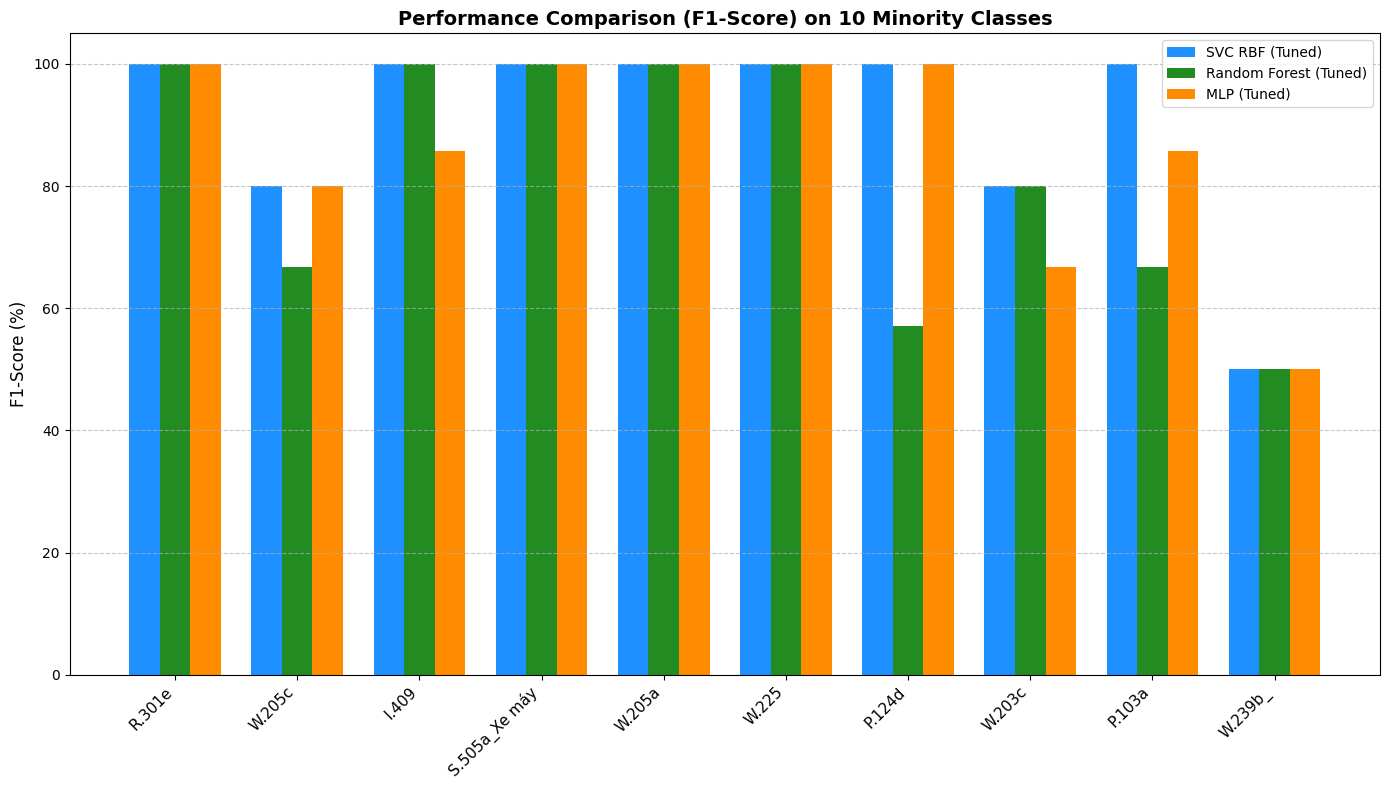

In [5]:
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

print("\nStarting Hyperparameter Tuning for ALL 6 MODELS (Step 3)...")
print("WARNING: This will take a VERY LONG time to complete.")
print("-" * 60)

tuning_configs = {
    "KNN": {
        "model": KNeighborsClassifier(n_jobs=-1),
        "params": {'n_neighbors': [3, 5, 7, 9]}
    },
    "SVC (RBF)": {
        "model": SVC(kernel='rbf', random_state=42),
        "params": {'C': [0.1, 1, 10, 100]}
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42, n_jobs=-1),
        "params": {'max_depth': [10, 20, None]}
    },
    "LightGBM": {
        "model": LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
        "params": {'learning_rate': [0.01, 0.1], 'n_estimators': [50, 100]}
    },
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=2000, random_state=42, n_jobs=-1),
        "params": {'C': [0.1, 1, 10]}
    },
    "MLP": {
        "model": MLPClassifier(max_iter=1000, random_state=42),
        "params": {'hidden_layer_sizes': [(50,), (100,)], 'alpha': [0.0001, 0.001]}
    }
}

best_params_dict = {}
tuning_results = []
minority_f1_scores = {} 

for name, config in tuning_configs.items():
    print(f"\n[>] Running GridSearchCV for {name}...")
    model = config["model"]
    param_grid = config["params"]

    model.fit(X_train_pca, y_train)
    base_pred = model.predict(X_test_pca)
    base_f1 = f1_score(y_test, base_pred, average='macro')

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1
    )
    grid_search.fit(X_train_pca, y_train)

    best_params = grid_search.best_params_
    best_params_dict[name] = best_params

    best_model = grid_search.best_estimator_
    tuned_pred = best_model.predict(X_test_pca)
    tuned_f1 = f1_score(y_test, tuned_pred, average='macro')

    f1_per_class = f1_score(y_test, tuned_pred, average=None, labels=classes)
    if name in ["SVC (RBF)", "Random Forest", "MLP"]:
        minority_f1_scores[name] = f1_per_class[minority_indices] * 100

    tuning_results.append({
        "Model": name,
        "Best Parameters": str(best_params),
        "Baseline F1 (Test)": round(base_f1, 4),
        "Tuned F1 (Test)": round(tuned_f1, 4),
        "Improvement": round(tuned_f1 - base_f1, 4)
    })

json_path = os.path.join(output_dir, 'best_params.json')
with open(json_path, 'w') as json_file:
    json.dump(best_params_dict, json_file, indent=4)
print(f"\n[V] Best parameters successfully saved to '{json_path}'")

tuning_df = pd.DataFrame(tuning_results)
print("\n" + "="*80)
print("STEP 3: TUNING COMPARISON (ALL 6 MODELS)")
print("="*80)
print(tuning_df.to_string(index=False))

x = np.arange(len(minority_classes))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 8))
rects1 = ax.bar(x - width, minority_f1_scores.get('SVC (RBF)', []), width, label='SVC RBF (Tuned)', color='dodgerblue')
rects2 = ax.bar(x, minority_f1_scores.get('Random Forest', []), width, label='Random Forest (Tuned)', color='forestgreen')
rects3 = ax.bar(x + width, minority_f1_scores.get('MLP', []), width, label='MLP (Tuned)', color='darkorange')

ax.set_ylabel('F1-Score (%)', fontsize=12)
ax.set_title('Performance Comparison (F1-Score) on 10 Minority Classes', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(minority_classes, rotation=45, ha='right', fontsize=11)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
minority_chart_path = os.path.join(figures_dir, 'M05_minority_classes_f1_comparison.png')
plt.savefig(minority_chart_path, dpi=300)
print(f"[V] Saved minority classes chart to: {minority_chart_path}")
plt.show()


[!] Best Model found: SVC (RBF)

CLASSIFICATION REPORT: SVC (RBF)
                       precision    recall  f1-score   support

                 B.8a       1.00      1.00      1.00         9
               Camera       1.00      1.00      1.00         4
               I.407a       1.00      1.00      1.00        20
                I.409       1.00      1.00      1.00         3
               I.434a       0.96      1.00      0.98        22
                P.102       0.98      1.00      0.99        47
               P.103a       1.00      0.67      0.80         6
                P.104       1.00      1.00      1.00         5
        P.106a_Xe tải       1.00      0.89      0.94         9
                P.107       1.00      1.00      1.00        22
                P.111       1.00      1.00      1.00        47
               P.117_       1.00      1.00      1.00         8
               P.123a       0.96      1.00      0.98        25
               P.123b       0.95      0.95      0.

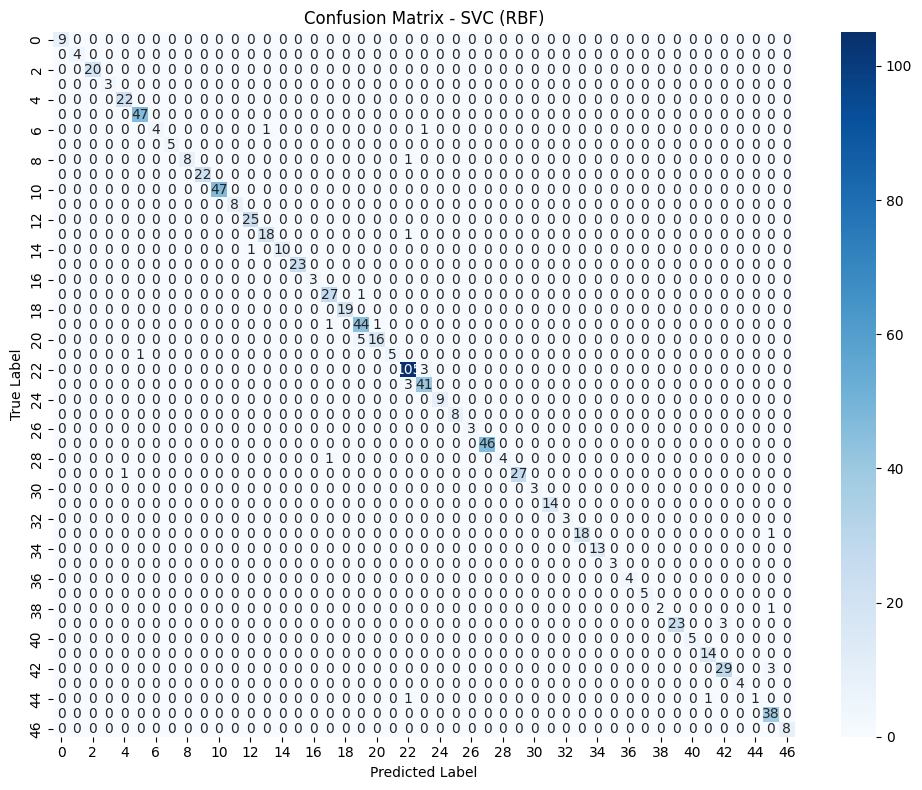

C:\Users\Hi\AppData\Local\Temp\ipykernel_3248\1797652453.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Tuned F1 (Test)', data=tuning_df, palette='viridis')


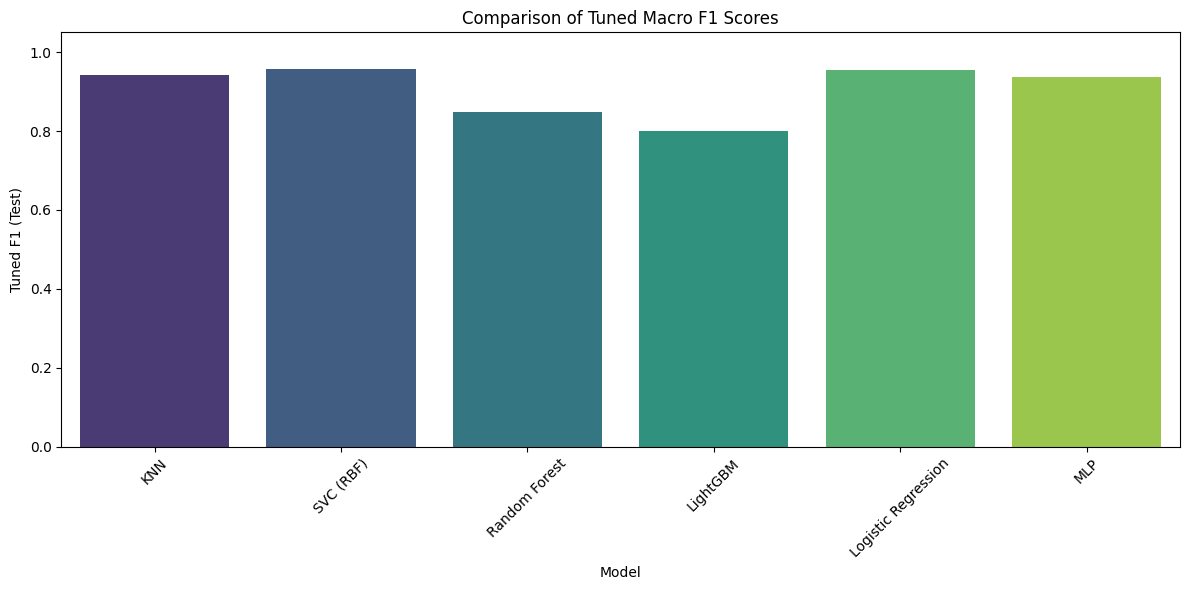

[V] Saved Trade-off chart to: outputs\figures\M05_f1_vs_inference_speed.png


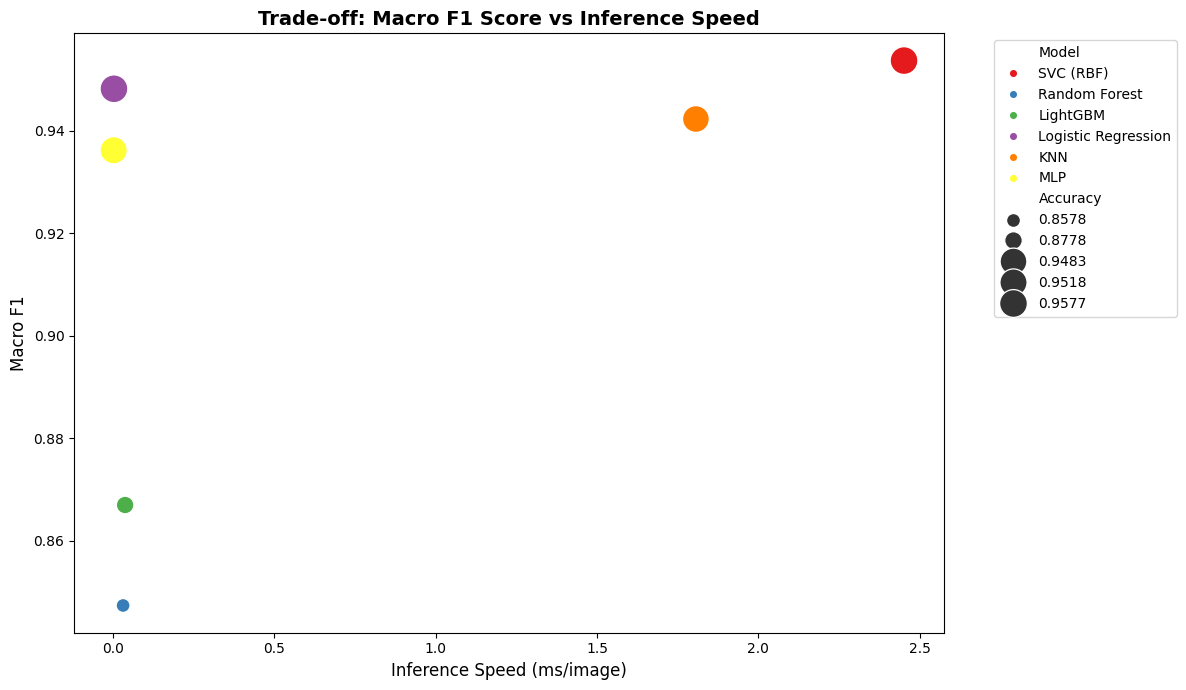

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

best_idx = tuning_df['Tuned F1 (Test)'].idxmax()
best_model_name = tuning_df.loc[best_idx, 'Model']
print(f"\n[!] Best Model found: {best_model_name}")

best_params = best_params_dict[best_model_name]
best_model = tuning_configs[best_model_name]["model"]
best_model.set_params(**best_params)

best_model.fit(X_train_pca, y_train)
y_pred_best = best_model.predict(X_test_pca)

print("\n" + "="*60)
print(f"CLASSIFICATION REPORT: {best_model_name.upper()}")
print("="*60)
print(classification_report(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Tuned F1 (Test)', data=tuning_df, palette='viridis')
plt.title('Comparison of Tuned Macro F1 Scores')
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

import seaborn as sns

plt.figure(figsize=(12, 7))
sns.scatterplot(
    x='Inference Speed (ms/image)', 
    y='Macro F1', 
    hue='Model', 
    size='Accuracy',
    sizes=(100, 400),
    data=results_df, 
    palette='Set1'
)

plt.title('Trade-off: Macro F1 Score vs Inference Speed', fontsize=14, fontweight='bold')
plt.ylabel('Macro F1', fontsize=12)
plt.xlabel('Inference Speed (ms/image)', fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

tradeoff_chart_path = os.path.join(figures_dir, 'M05_f1_vs_inference_speed.png')
plt.savefig(tradeoff_chart_path, dpi=300)
print(f"[V] Saved Trade-off chart to: {tradeoff_chart_path}")
plt.show()